   reading  Delta_Change
0     22.5           0.0
1     23.1           0.6
2     22.8          -0.3
3     24.0           1.2
4     24.3           0.3


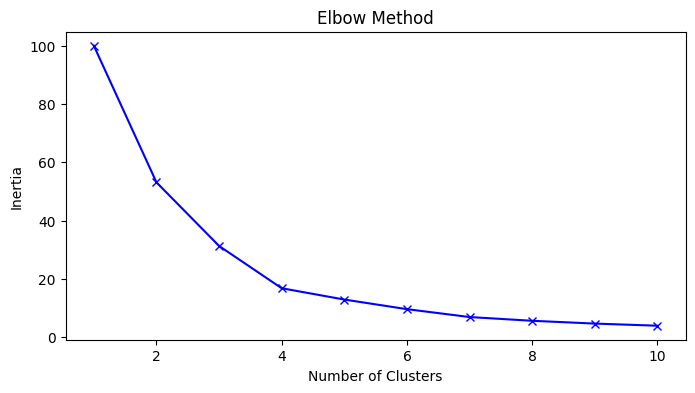


Clustered Data:
   reading  Delta_Change  Inherent_Cluster
0     22.5           0.0                 1
1     23.1           0.6                 0
2     22.8          -0.3                 1
3     24.0           1.2                 0
4     24.3           0.3                 0

Silhouette Score:
0.4808157926191231


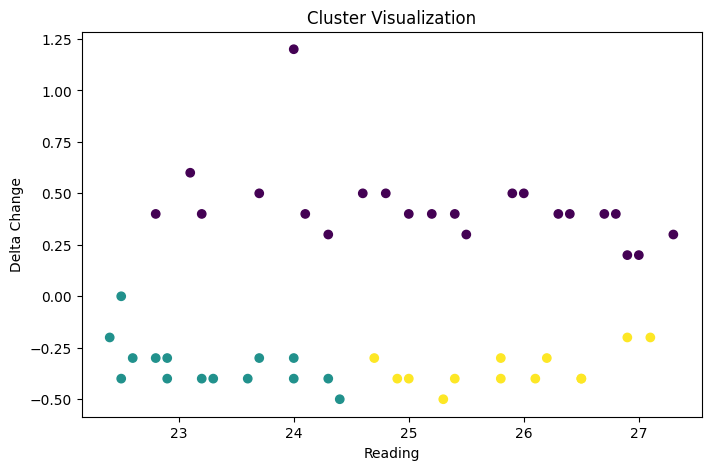

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# STEP 1: LOAD DATA

df = pd.read_csv(
    'lab_analytical_cache.csv'
)

print(df.head())


# STEP 2: FEATURE SELECTION

X = df[['reading', 'Delta_Change']]


# STEP 3: FEATURE SCALING

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# STEP 4: ELBOW METHOD

inertia_scores = []

K_range = range(1, 11)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    model.fit(X_scaled)

    inertia_scores.append(model.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,4))

plt.plot(
    K_range,
    inertia_scores,
    'bx-'
)

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.show()


# STEP 5: FINAL CLUSTERING

optimal_k = 3

final_model = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    random_state=42
)

cluster_labels = final_model.fit_predict(
    X_scaled
)

# Add labels

df['Inherent_Cluster'] = cluster_labels

print("\nClustered Data:")
print(df.head())


# STEP 6: SILHOUETTE SCORE

score = silhouette_score(
    X_scaled,
    cluster_labels
)

print("\nSilhouette Score:")
print(score)


# STEP 7: VISUALIZATION

plt.figure(figsize=(8,5))

plt.scatter(
    df['reading'],
    df['Delta_Change'],
    c=df['Inherent_Cluster']
)

plt.xlabel('Reading')

plt.ylabel('Delta Change')

plt.title('Cluster Visualization')

plt.show()